In [9]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d

import paths as p
import utils

In [10]:
heatmap_dir = os.path.join(p.FIGURES_DIR, 'heatmaps', 'by_peak_time')
if not os.path.exists(heatmap_dir):
    os.makedirs(heatmap_dir)

In [11]:
units_vetted = pd.read_csv(os.path.join(p.LOGS_DIR, 'units_vetted.csv'), index_col=0).sort_values('unit_id')
sessions_vetted = pd.read_csv(os.path.join(p.LOGS_DIR, 'sessions_vetted.csv'), index_col=0).sort_values('num_units', ascending=False)

In [13]:
sessions_vetted

,date,mouse,insertion_number,region,potential problems,sorting notes,First_X_Column,datetime,paramset_idx,num_units,id,group,cohort,length,num_trials,num_missed,percent_missed,num_bg_penalty,percent_bg_penalty,wait_length_mean
72,2025-03-12,RZ061,0,str,name changed from r to l,NaN,Done,2025-03-12 11:12:18,101,208,RZ061_2025-03-12_str,s,7,2748.504763,297,0,0.000000,146,49.158249,4.924514
82,2025-03-05,RZ062,1,str,NaN,NaN,Done,2025-03-05 11:45:26,101,183,RZ062_2025-03-05_str,s,7,4179.361089,687,0,0.000000,389,56.622999,1.373048
90,2025-02-22,RZ065,1,str,NaN,NaN,Done,2025-02-22 13:03:06,101,162,RZ065_2025-02-22_str,l,7,5265.110723,365,8,2.191781,166,45.479452,4.910904
85,2025-03-07,RZ063,0,str,NaN,NaN,Done,2025-03-07 14:01:15,101,121,RZ063_2025-03-07_str,s,7,2721.711856,363,0,0.000000,83,22.865014,3.287323
77,2025-03-04,RZ062,1,str,NaN,"great session with 120 units, but a good amout...",Done,2025-03-04 11:06:58,101,112,RZ062_2025-03-04_str,s,7,3808.111739,529,0,0.000000,289,54.631380,2.532453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,2025-03-14,RZ058,0,v1,NaN,NaN,Done,2025-03-14 13:55:36,101,3,RZ058_2025-03-14_v1,l,7,4444.292514,328,6,1.829268,95,28.963415,4.829923
29,2024-11-22,RZ050,0,v1,NaN,NaN,Done,2024-11-22 13:09:01,101,3,RZ050_2024-11-22_v1,s,6,2834.446132,426,0,0.000000,123,28.873239,2.428788
12,2024-07-17,RZ038,0,v1,NaN,NaN,Done,2024-07-17 12:01:45,101,2,RZ038_2024-07-17_v1,l,5,3285.295805,104,16,15.384615,49,47.115385,23.436054
25,2024-11-21,RZ050,0,v1,NaN,probe 0 mostly noise,Done,2024-11-21 13:07:06,101,2,RZ050_2024-11-21_v1,s,6,2710.602408,375,0,0.000000,115,30.666667,3.010491


In [14]:
qc_pass = pd.read_csv(p.LOGS_DIR / "RZ_unit_properties_with_qc.csv")

In [15]:
qc_pass

,mouse,datetime,insertion_number,paramset_idx,id,firing_rate,snr,presence_ratio,isi_violation,number_violation,...,qc_pass_d_prime,qc_pass_silhouette_score,qc_pass_max_drift,qc_pass_cumulative_drift,qc_pass_firing_rate,qc_pass_isi_violation,qc_pass_amplitude_cutoff,qc_pass_presence_ratio,qc_pass_contamination_rate,qc_pass_all
0,RZ034,2024-07-13 12:58:26,1,101,7,3.020480,8.26081,1.000000,0.000000,0,...,True,False,True,True,True,True,True,True,True,True
1,RZ034,2024-07-13 12:58:26,1,101,8,0.694021,10.37970,0.904762,0.000000,0,...,True,False,False,False,True,True,True,True,True,True
2,RZ034,2024-07-13 12:58:26,1,101,13,7.173250,3.92182,1.000000,0.048207,19,...,True,False,True,True,True,True,True,True,True,True
3,RZ034,2024-07-13 12:58:26,1,101,14,5.418220,8.12457,1.000000,0.004447,1,...,True,False,True,True,True,True,True,True,True,True
4,RZ034,2024-07-13 12:58:26,1,101,16,3.447000,9.80236,1.000000,0.065926,6,...,True,False,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3490,RZ065,2025-02-22 13:03:06,1,101,611,1.832520,4.56166,1.000000,0.371942,20,...,True,False,False,False,True,True,True,True,False,False
3491,RZ065,2025-02-22 13:03:06,1,101,613,0.839353,7.07135,1.000000,0.088645,1,...,True,False,False,False,True,True,True,True,True,True
3492,RZ070,2025-02-13 11:40:15,1,101,0,30.687200,5.22955,1.000000,0.043029,276,...,False,False,True,True,True,True,True,True,True,True
3493,RZ070,2025-02-13 11:40:15,1,101,14,18.840100,4.76070,1.000000,0.025645,62,...,False,False,True,True,True,True,True,True,True,True


In [12]:
units_qc_all = pd.read_csv(p.LOGS_DIR / "qc_per_unit_with_pass_flags.csv")
units_qc = units_qc_all[units_qc_all['qc_pass_all'] == True]
units_per_session = units_qc.groupby('session_id').size().reset_index(name='unit_count')
sessions_vetted = sessions_vetted.merge(
    units_per_session[['session_id', 'unit_count']],
    how='left',
    left_on='id',
    right_on='session_id'
).rename(columns={'unit_count': 'unit_qc_pass_count'})

KeyError: 'session_id'

In [5]:
sessions_filtered = sessions_vetted[sessions_vetted['unit_qc_pass_count'] >= 60]
len(sessions_filtered)

7

In [6]:
time_step = 0.1

In [15]:
def plot_trial_heatmap(trial_spikes_df, trial_info, session_info, time_step, fig_path, save_fig=True, sigma=1):
    unit_ids = trial_spikes_df['unit_id'].unique()
    heatmap_data = []
    for unit_id in unit_ids:
        trial_spikes_unit = trial_spikes_df.loc[trial_spikes_df['unit_id'] == unit_id]
        bounds = (0, trial_info['trial_length'])
        bin_edges = np.arange(bounds[0] - time_step, bounds[1] + 2*time_step, time_step)
        counts = np.histogram(trial_spikes_unit['trial_time'], bins=bin_edges)[0]
        rates = counts / time_step
        rates_smoothed = gaussian_filter1d(rates, sigma=sigma)
        normalized_rates = (rates_smoothed - rates_smoothed.mean()) / rates_smoothed.std()
        heatmap_data.append(normalized_rates)

    heatmap_data = np.array(heatmap_data)
    max_bin_indices = np.argmax(heatmap_data, axis=1)
    sorted_indices = np.argsort(max_bin_indices)
    sorted_heatmap = heatmap_data[sorted_indices]

    vmax = np.percentile(np.abs(sorted_heatmap), 95)
    vmin = -vmax

    plt.figure(figsize=(6, 6))
    extent = [0, sorted_heatmap.shape[1]*time_step, 0, sorted_heatmap.shape[0]]  # x axis in seconds
    plt.imshow(
        sorted_heatmap, 
        aspect='auto', 
        cmap='viridis',
        interpolation='nearest',
        vmin=vmin,
        vmax=vmax,
        extent=extent
    )
    plt.xlabel('Time (s)')
    plt.xlim(0, sorted_heatmap.shape[1]*time_step)
    plt.ylabel('Unit (sorted by peak firing time)')
    plt.title(f'{session_info["id"]}_trial-{trial_info["trial_id"]}')

    # Plot vertical dashed lines for trial events
    if 'cue_on_time' in trial_info and not pd.isna(trial_info['cue_on_time']):
        plt.axvline(trial_info['cue_on_time'], color='g', linestyle='--', linewidth=2, label='Cue On')
    if 'cue_off_time' in trial_info and not pd.isna(trial_info['cue_off_time']):
        plt.axvline(trial_info['cue_off_time'], color='orange', linestyle='--', linewidth=2, label='Cue Off')
    if 'decision_time' in trial_info and not pd.isna(trial_info['decision_time']):
        decision_color = 'b' if trial_info.get('rewarded', False) else 'r'
        plt.axvline(trial_info['decision_time'], color=decision_color, linestyle='--', linewidth=2, label='Decision')
    
    if save_fig:
        plt.savefig(fig_path)
        plt.close()
    else:
        plt.show()

In [ ]:
# sessions_grouped = sessions_filtered.groupby("region")
# total_trials = sum(len(utils.get_session_data(session_info['id'])[1]) for _, session_info in sessions_filtered.iterrows())

# with tqdm(total=total_trials, desc="Processing trials", unit="trial") as pbar:
#     for region, region_sessions in sessions_grouped:
#         region_folder = os.path.join(heatmap_dir, region)
#         os.makedirs(region_folder, exist_ok=True)
#         for _, session_info in region_sessions.iterrows():
#             events, trials, units = utils.get_session_data(session_info['id'])
#             for t, trial_info in trials.iterrows():
#                 trial_id = trial_info['trial_id']
#                 trial_spikes_list = []
#                 for idx, unit in units.items():
#                     trial_spikes = unit.loc[unit['trial_id'] == trial_id].copy()
#                     if not trial_spikes.empty:
#                         trial_spikes.loc[:, 'unit_id'] = idx
#                         trial_spikes_list.append(trial_spikes)
#                 if not trial_spikes_list:
#                     pbar.update(1)
#                     continue
#                 trial_spikes_df = pd.concat(trial_spikes_list)
#                 tw_rounded = round(trial_info['wait_length'], 2)
#                 fig_path = os.path.join(
#                     region_folder,
#                     f"{session_info['id']}_tw{tw_rounded}_trial-{trial_id}_firing_rate_heatmap.png"
#                 )
#                 plot_trial_heatmap(trial_spikes_df, trial_info, session_info, time_step, fig_path)
#                 pbar.update(1)

In [16]:
def plot_trial_heatmap_side_by_side(
    trial_spikes_df, trial_info, session_info, time_step, fig_path, save_fig=True, sigma=1, time_norm=("cue_on_time", "decision_time"), n_bins_norm=100
):
    """
    Plots two heatmaps for a trial:
    - Left: regular (absolute time, seconds)
    - Right: normalized window (0-1, e.g. cue_on to decision)
    """
    def get_sorted_heatmap(trial_spikes_df, unit_ids, bin_edges, sigma, time_col="trial_time"):
        heatmap = []
        for unit_id in unit_ids:
            times = trial_spikes_df.loc[trial_spikes_df["unit_id"] == unit_id, time_col].to_numpy()
            counts = None
            if times.size == 0 or (counts := np.histogram(times, bins=bin_edges)[0]).sum() == 0:
                continue  # skip this unit entirely if no spikes in window
            rates = counts / np.diff(bin_edges)[0]
            rates_smoothed = gaussian_filter1d(rates, sigma=sigma)
            sd = rates_smoothed.std()
            if sd == 0:
                normalized = rates_smoothed * 0.0
            else:
                normalized = (rates_smoothed - rates_smoothed.mean()) / sd
            heatmap.append(normalized)
        heatmap = np.array(heatmap)
        max_bin_indices = np.argmax(heatmap, axis=1)
        sorted_indices = np.argsort(max_bin_indices)
        return heatmap[sorted_indices]

    fig, axes = plt.subplots(1, 2, figsize=(10, 6))
    unit_ids = trial_spikes_df["unit_id"].unique()

    # --- Absolute time heatmap ---
    abs_bin_edges = np.arange(0, trial_info["trial_length"] + time_step, time_step)
    abs_heatmap = get_sorted_heatmap(trial_spikes_df, unit_ids, abs_bin_edges, sigma, time_col="trial_time")
    vmax = np.percentile(np.abs(abs_heatmap), 95)
    im0 = axes[0].imshow(
        abs_heatmap,
        aspect="auto",
        cmap="viridis",
        interpolation="nearest",
        vmin=-vmax,
        vmax=vmax,
        extent=[0, abs_heatmap.shape[1] * time_step, 0, abs_heatmap.shape[0]],
    )
    axes[0].set(xlabel="Time (s)", ylabel="Unit (sorted by peak firing time)", title="Absolute Time")
    for event, color in zip(["cue_on_time", "cue_off_time", "decision_time"], ["g", "orange", "b"]):
        t = trial_info.get(event, np.nan)
        if pd.notna(t):
            c = color if event != "decision_time" else ("b" if trial_info.get("rewarded", False) else "r")
            axes[0].axvline(t, color=c, linestyle="--", linewidth=2)

    # --- Normalized time heatmap ---
    start_key, end_key = time_norm
    t_start, t_end = trial_info.get(start_key, np.nan), trial_info.get(end_key, np.nan)
    if not (pd.notna(t_start) and pd.notna(t_end) and (t_end > t_start)):
        axes[1].set_title("Cannot normalize: missing or invalid start/end times.")
    else:
        norm_bin_edges = np.linspace(0.0, 1.0, n_bins_norm + 1)
        trial_spikes_df = trial_spikes_df.copy()
        trial_spikes_df["norm_time"] = (trial_spikes_df["trial_time"] - t_start) / (t_end - t_start)
        mask_01 = (trial_spikes_df["norm_time"] >= 0.0) & (trial_spikes_df["norm_time"] < 1.0)
        trial_spikes_df = trial_spikes_df.loc[mask_01]
        norm_heatmap = get_sorted_heatmap(trial_spikes_df, unit_ids, norm_bin_edges, sigma, time_col="norm_time")
        vmax = np.percentile(np.abs(norm_heatmap), 95)
        im1 = axes[1].imshow(
            norm_heatmap,
            aspect="auto",
            cmap="viridis",
            interpolation="nearest",
            vmin=-vmax,
            vmax=vmax,
            extent=[0, 1, 0, norm_heatmap.shape[0]],
        )
        axes[1].set(xlabel="Normalized time (start→decision)", ylabel="Unit (sorted by peak firing time)", title="Normalized Window")
        # Event lines
        def _warp(t): return (t - t_start) / (t_end - t_start)
        for event, color in zip(["cue_on_time", "cue_off_time", "decision_time"], ["g", "orange", "b"]):
            t = trial_info.get(event, np.nan)
            if pd.notna(t):
                c = color if event != "decision_time" else ("b" if trial_info.get("rewarded", False) else "r")
                axes[1].axvline(_warp(t), color=c, linestyle="--", linewidth=2)

    plt.suptitle(f'{session_info["id"]}_trial-{trial_info["trial_id"]}')
    plt.tight_layout()
    if save_fig:
        plt.savefig(fig_path)
        plt.close(fig)
    else:
        plt.show()


In [ ]:
# sessions_grouped = sessions_filtered.groupby("region")
# total_trials = sum(len(utils.get_session_data(session_info['id'])[1]) for _, session_info in sessions_filtered.iterrows())
# heatmap_dir_with_normalization = os.path.join(p.FIGURES_DIR, 'heatmaps', 'by_peak_time_reg_normalized')

# with tqdm(total=total_trials, desc="Processing trials", unit="trial") as pbar:
#     for region, region_sessions in sessions_grouped:
#         region_folder = os.path.join(heatmap_dir_with_normalization, region)
#         os.makedirs(region_folder, exist_ok=True)
#         for _, session_info in region_sessions.iterrows():
#             events, trials, units = utils.get_session_data(session_info['id'])
#             for t, trial_info in trials.iterrows():
#                 trial_id = trial_info['trial_id']
#                 trial_spikes_list = []
#                 for idx, unit in units.items():
#                     trial_spikes = unit.loc[unit['trial_id'] == trial_id].copy()
#                     if not trial_spikes.empty:
#                         trial_spikes.loc[:, 'unit_id'] = idx
#                         trial_spikes_list.append(trial_spikes)
#                 if not trial_spikes_list:
#                     pbar.update(1)
#                     continue
#                 trial_spikes_df = pd.concat(trial_spikes_list)
#                 tw_rounded = round(trial_info['wait_length'], 2)
#                 fig_path = os.path.join(
#                     region_folder,
#                     f"{session_info['id']}_tw{tw_rounded}_trial-{trial_id}_firing_rate_heatmap_dual.png"
#                 )
#                 plot_trial_heatmap_side_by_side(trial_spikes_df, trial_info, session_info, time_step, fig_path, 
#                                                 save_fig=True, sigma=1, time_norm=("cue_on_time", "decision_time"), n_bins_norm=100)
#                 pbar.update(1)

In [21]:
def plot_trial_heatmap_5plots(
    trial_spikes_df, trial_info, session_info, time_step, fig_path, save_fig=True, sigma=1, n_bins_norm=100
):
    """
    Plots five heatmaps for a trial:
    - 1: Absolute time (seconds)
    - 2: Normalized cue_on → decision
    - 3: Normalized cue_on → cue_off
    - 4: Normalized cue_off → decision
    - 5: Normalized decision → trial_end
    All normalized plots have x-axis from 0 to 1.
    """
    def get_sorted_heatmap(trial_spikes_df, unit_ids, bin_edges, sigma, time_col="trial_time"):
        heatmap = []
        for unit_id in unit_ids:
            times = trial_spikes_df.loc[trial_spikes_df["unit_id"] == unit_id, time_col].to_numpy()
            counts = None
            if times.size == 0 or (counts := np.histogram(times, bins=bin_edges)[0]).sum() == 0:
                continue  # skip this unit entirely if no spikes in window
            rates = counts / np.diff(bin_edges)[0]
            rates_smoothed = gaussian_filter1d(rates, sigma=sigma)
            sd = rates_smoothed.std()
            if sd == 0:
                normalized = rates_smoothed * 0.0
            else:
                normalized = (rates_smoothed - rates_smoothed.mean()) / sd
            heatmap.append(normalized)
        heatmap = np.array(heatmap)
        if heatmap.size == 0:
            return heatmap
        max_bin_indices = np.argmax(heatmap, axis=1)
        sorted_indices = np.argsort(max_bin_indices)
        return heatmap[sorted_indices]

    norm_windows = [
        ("cue_on_time", "decision_time", "Norm: cue_on→decision"),
        ("cue_on_time", "cue_off_time", "Norm: cue_on→cue_off"),
        ("cue_off_time", "decision_time", "Norm: cue_off→decision"),
        ("decision_time", "trial_length", "Norm: decision→trial_end"),
    ]

    fig, axes = plt.subplots(1, 1 + len(norm_windows), figsize=(5 * (1 + len(norm_windows)), 6))
    if len(norm_windows) == 1:
        axes = [axes]
    unit_ids = trial_spikes_df["unit_id"].unique()

    # --- Absolute time heatmap ---
    abs_bin_edges = np.arange(0, trial_info["trial_length"] + time_step, time_step)
    abs_heatmap = get_sorted_heatmap(trial_spikes_df, unit_ids, abs_bin_edges, sigma, time_col="trial_time")
    vmax = np.percentile(np.abs(abs_heatmap), 95) if abs_heatmap.size > 0 else 1
    im0 = axes[0].imshow(
        abs_heatmap,
        aspect="auto",
        cmap="viridis",
        interpolation="nearest",
        vmin=-vmax,
        vmax=vmax,
        extent=[0, abs_heatmap.shape[1] * time_step if abs_heatmap.size > 0 else 1, 0, abs_heatmap.shape[0] if abs_heatmap.size > 0 else 1],
    )
    axes[0].set(xlabel="Time (s)", ylabel="Unit (sorted by peak firing time)", title="Absolute Time")
    for event, color in zip(["cue_on_time", "cue_off_time", "decision_time"], ["g", "orange", "b"]):
        t = trial_info.get(event, np.nan)
        if pd.notna(t):
            c = color if event != "decision_time" else ("b" if trial_info.get("rewarded", False) else "r")
            axes[0].axvline(t, color=c, linestyle="--", linewidth=2)

    # --- Normalized time heatmaps ---
    for i, (start_key, end_key, title) in enumerate(norm_windows):
        ax = axes[i + 1]
        # For 'trial_length', use the value directly from trial_info, not as a key
        t_start = trial_info.get(start_key, np.nan)
        if end_key == "trial_length":
            t_end = trial_info["trial_length"]
        else:
            t_end = trial_info.get(end_key, np.nan)
        if not (pd.notna(t_start) and pd.notna(t_end) and (t_end > t_start)):
            ax.set_title(f"Cannot normalize: missing or invalid {start_key}/{end_key}.")
            ax.set_xlim(0, 1)
            continue
        norm_bin_edges = np.linspace(0.0, 1.0, n_bins_norm + 1)
        trial_spikes_df_norm = trial_spikes_df.copy()
        trial_spikes_df_norm["norm_time"] = (trial_spikes_df_norm["trial_time"] - t_start) / (t_end - t_start)
        mask_01 = (trial_spikes_df_norm["norm_time"] >= 0.0) & (trial_spikes_df_norm["norm_time"] < 1.0)
        trial_spikes_df_norm = trial_spikes_df_norm.loc[mask_01]
        norm_heatmap = get_sorted_heatmap(trial_spikes_df_norm, unit_ids, norm_bin_edges, sigma, time_col="norm_time")
        vmax = np.percentile(np.abs(norm_heatmap), 95) if norm_heatmap.size > 0 else 1
        im = ax.imshow(
            norm_heatmap,
            aspect="auto",
            cmap="viridis",
            interpolation="nearest",
            vmin=-vmax,
            vmax=vmax,
            extent=[0, 1, 0, norm_heatmap.shape[0] if norm_heatmap.size > 0 else 1],
        )
        ax.set(xlabel="Normalized time (0-1)", ylabel="Unit (sorted by peak firing time)", title=title, xlim=(0, 1))
        # Event lines
        def _warp(t): return (t - t_start) / (t_end - t_start)
        for event, color in zip(["cue_on_time", "cue_off_time", "decision_time"], ["g", "orange", "b"]):
            t = trial_info.get(event, np.nan)
            if pd.notna(t):
                c = color if event != "decision_time" else ("b" if trial_info.get("rewarded", False) else "r")
                ax.axvline(_warp(t), color=c, linestyle="--", linewidth=2)

    plt.suptitle(f'{session_info["id"]}_trial-{trial_info["trial_id"]}')
    plt.tight_layout()
    if save_fig:
        plt.savefig(fig_path)
        plt.close(fig)
    else:
        plt.show()


In [23]:
sessions_grouped = sessions_filtered.groupby("region")
total_trials = sum(len(utils.get_session_data(session_info['id'])[1]) for _, session_info in sessions_filtered.iterrows())
heatmap_dir_with_normalization = os.path.join(p.FIGURES_DIR, 'heatmaps', 'by_peak_time_reg_normalized_5plots')

with tqdm(total=total_trials, desc="Processing trials", unit="trial") as pbar:
    for region, region_sessions in sessions_grouped:
        region_folder = os.path.join(heatmap_dir_with_normalization, region)
        os.makedirs(region_folder, exist_ok=True)
        for _, session_info in region_sessions.iterrows():
            events, trials, units = utils.get_session_data(session_info['id'])
            for t, trial_info in trials.iterrows():
                trial_id = trial_info['trial_id']
                trial_spikes_list = []
                for idx, unit in units.items():
                    trial_spikes = unit.loc[unit['trial_id'] == trial_id].copy()
                    if not trial_spikes.empty:
                        trial_spikes.loc[:, 'unit_id'] = idx
                        trial_spikes_list.append(trial_spikes)
                if not trial_spikes_list:
                    pbar.update(1)
                    continue
                trial_spikes_df = pd.concat(trial_spikes_list)
                tw_rounded = round(trial_info['wait_length'], 2)
                fig_path = os.path.join(
                    region_folder,
                    f"{session_info['id']}_tw{tw_rounded}_trial-{trial_id}_firing_rate_heatmap_5plots.png"
                )
                plot_trial_heatmap_5plots(trial_spikes_df, trial_info, session_info, time_step, fig_path, 
                                           save_fig=True, sigma=1, n_bins_norm=100)
                pbar.update(1)

Processing trials: 100%|██████████| 3067/3067 [26:38<00:00,  1.92trial/s]


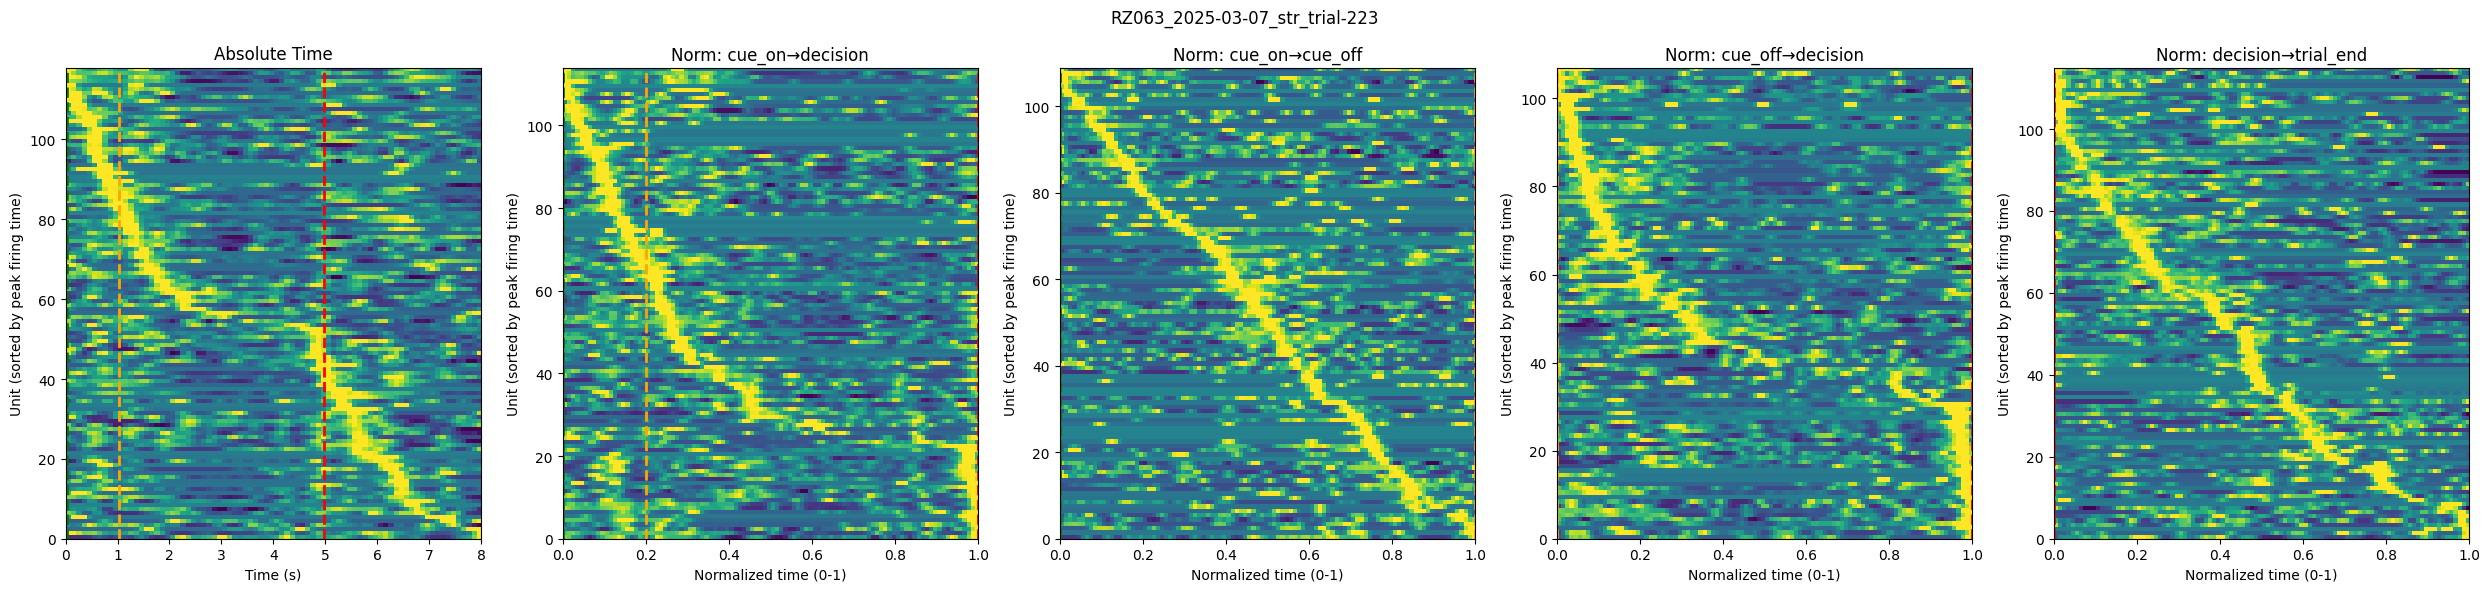

In [22]:
# single trial test
session_id = "RZ063_2025-03-07_str"
trial_id = 223

session_info = sessions_filtered.loc[sessions_filtered['id'] == session_id].iloc[0]
events, trials, units = utils.get_session_data(session_info['id'])
trial_info = trials.loc[trials['trial_id'] == trial_id].iloc[0]
trial_spikes_list = []
for idx, unit in units.items():
    trial_spikes = unit.loc[unit['trial_id'] == trial_id].copy()
    if not trial_spikes.empty:
        trial_spikes.loc[:, 'unit_id'] = idx
        trial_spikes_list.append(trial_spikes)
trial_spikes_df = pd.concat(trial_spikes_list)
tw_rounded = round(trial_info['wait_length'], 2)
fig_path = os.path.join(
    heatmap_dir,
    f"{session_info['id']}_tw{tw_rounded}_trial-{trial_id}_firing_rate_heatmap.png"
)
save_fig = False
# plot_trial_heatmap(trial_spikes_df, trial_info, session_info, time_step, fig_path, save_fig)
# plot_trial_heatmap_side_by_side(trial_spikes_df, trial_info, session_info, time_step, fig_path, save_fig, sigma=1, time_norm=('cue_on_time','decision_time'), n_bins_norm=100)
plot_trial_heatmap_5plots(trial_spikes_df, trial_info, session_info, time_step, fig_path, save_fig, sigma=1, n_bins_norm=100)

poster examples

In [24]:
# --- Plot three trials side by side ---
def plot_trial_heatmap_on_ax(ax, trial_spikes_df, trial_info, session_info, time_step, sigma=1):
    unit_ids = trial_spikes_df['unit_id'].unique()
    heatmap_data = []
    for unit_id in unit_ids:
        trial_spikes_unit = trial_spikes_df.loc[trial_spikes_df['unit_id'] == unit_id]
        bounds = (0, trial_info['trial_length'])
        bin_edges = np.arange(bounds[0] - time_step, bounds[1] + 2*time_step, time_step)
        counts = np.histogram(trial_spikes_unit['trial_time'], bins=bin_edges)[0]
        rates = counts / time_step
        rates_smoothed = gaussian_filter1d(rates, sigma=sigma)
        normalized_rates = (rates_smoothed - rates_smoothed.mean()) / rates_smoothed.std()
        heatmap_data.append(normalized_rates)

    heatmap_data = np.array(heatmap_data)
    max_bin_indices = np.argmax(heatmap_data, axis=1)
    sorted_indices = np.argsort(max_bin_indices)
    sorted_heatmap = heatmap_data[sorted_indices]

    vmax = np.percentile(np.abs(sorted_heatmap), 95)
    vmin = -vmax

    extent = [0, sorted_heatmap.shape[1]*time_step, 0, sorted_heatmap.shape[0]]  # x axis in seconds
    im = ax.imshow(
        sorted_heatmap, 
        aspect='auto', 
        cmap='viridis',
        interpolation='nearest',
        vmin=vmin,
        vmax=vmax,
        extent=extent
    )
    ax.set_xlabel('Time (s)')
    ax.set_xlim(0, sorted_heatmap.shape[1]*time_step)
    ax.set_ylabel('Unit (sorted by peak firing time)')
    ax.set_title(f'{session_info["id"]}-trial_{trial_info["trial_id"]}')

    # Plot vertical dashed lines for trial events (no label, so no legend)
    if 'cue_on_time' in trial_info and not pd.isna(trial_info['cue_on_time']):
        ax.axvline(trial_info['cue_on_time'], color='g', linestyle='--', linewidth=4)
    if 'cue_off_time' in trial_info and not pd.isna(trial_info['cue_off_time']):
        ax.axvline(trial_info['cue_off_time'], color='orange', linestyle='--', linewidth=4)
    if 'decision_time' in trial_info and not pd.isna(trial_info['decision_time']):
        decision_color = 'b' if trial_info.get('rewarded', False) else 'r'
        ax.axvline(trial_info['decision_time'], color=decision_color, linestyle='--', linewidth=4)
    return im

In [25]:
rewarded_trials = [
    ("RZ062_2025-03-05_str", 387),
    ("RZ050_2024-11-20_str", 34),
    ("RZ061_2025-03-12_str", 146),
    ("RZ057_2025-03-13_str", 129)
]

unrewarded_trials = [
    ("RZ063_2025-03-07_str", 223),
    ("RZ050_2024-11-20_str", 17),
    ("RZ062_2025-03-05_str", 248),
    ("RZ061_2025-03-12_str", 71)
]

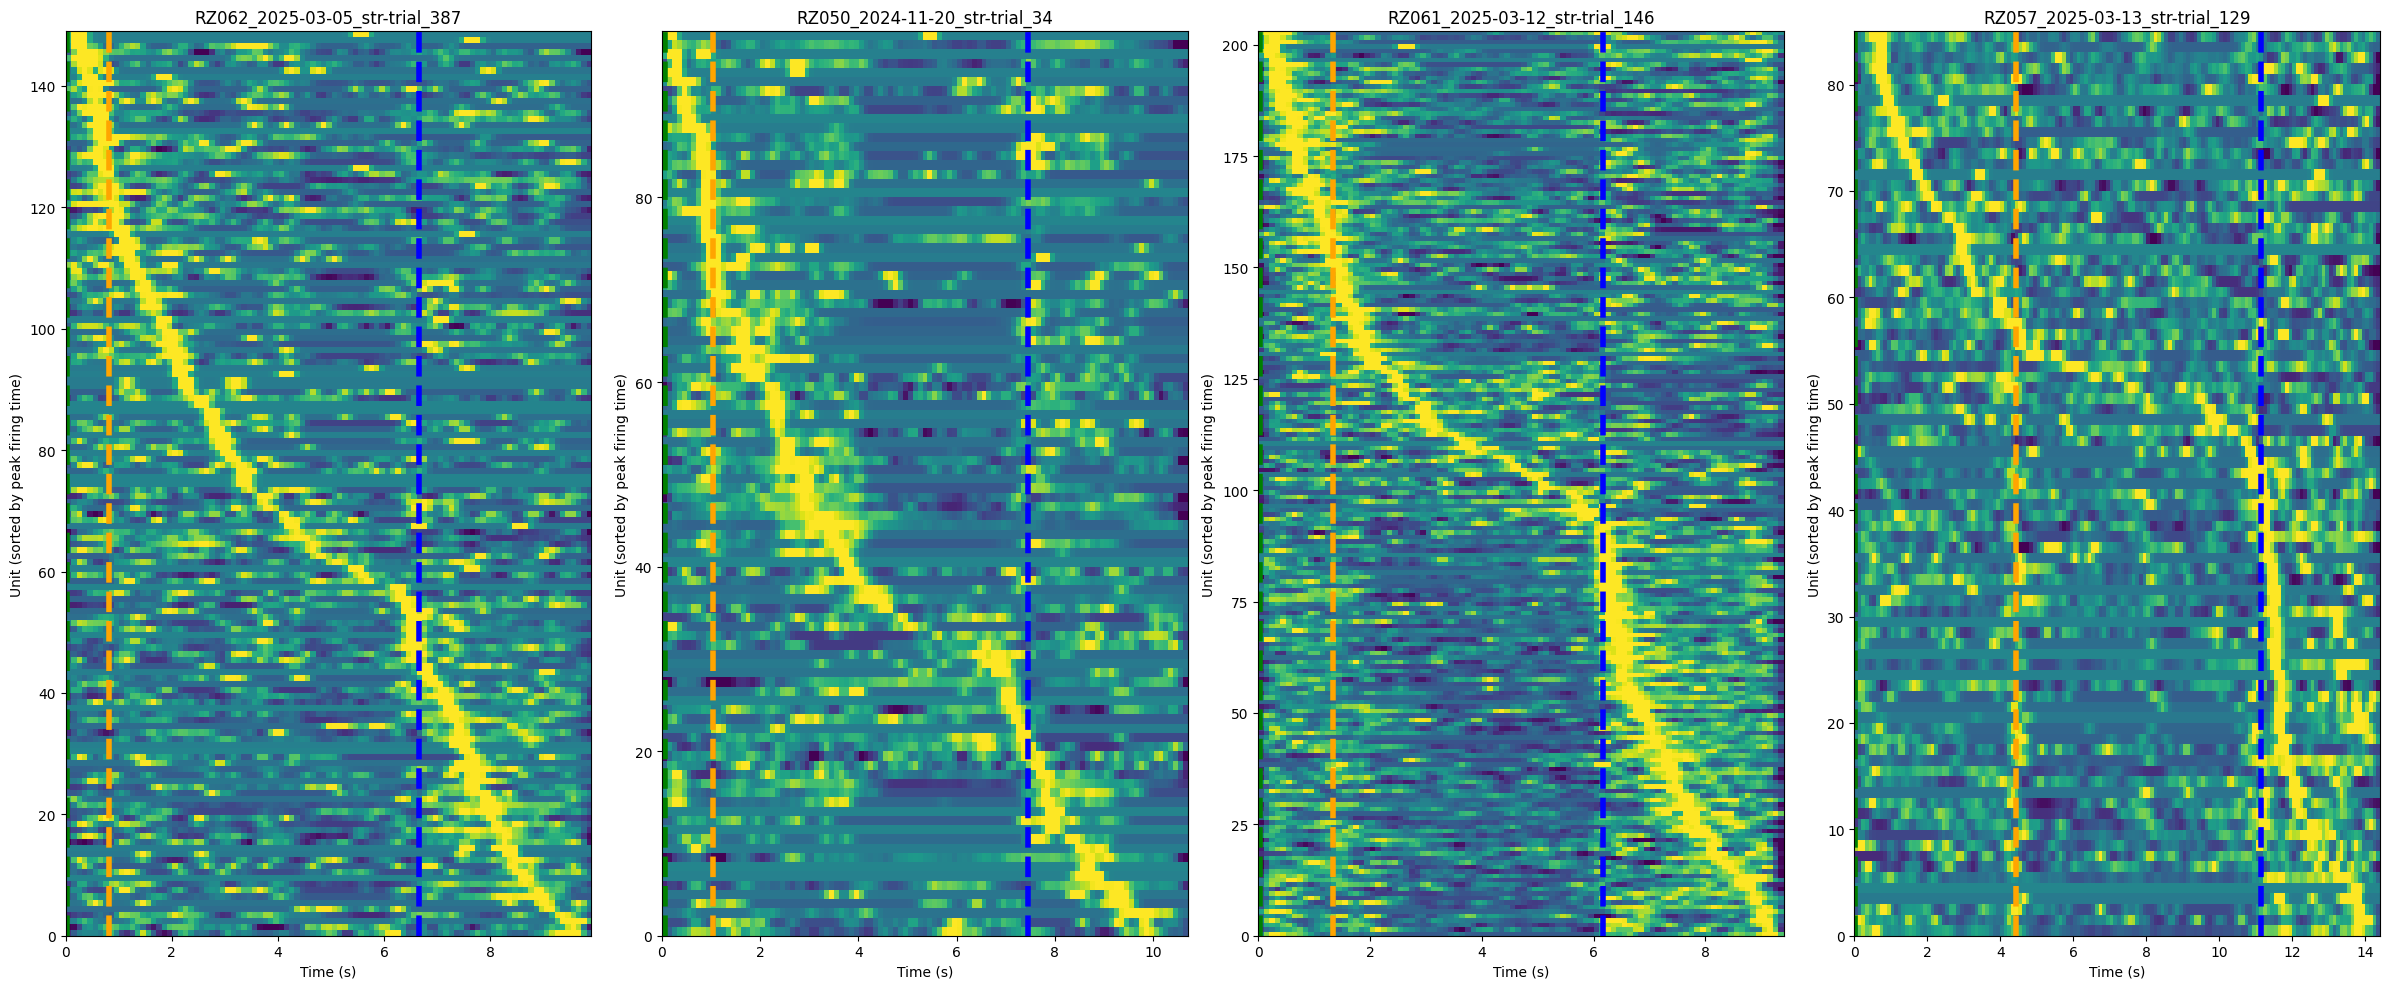

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(24, 10))
ims = []

for i, (session_id, trial_id) in enumerate(rewarded_trials):
    session_info = sessions_vetted.loc[sessions_vetted['id'] == session_id].iloc[0]
    events, trials, units = utils.get_session_data(session_info['id'])
    trial_info = trials.loc[trials['trial_id'] == trial_id].iloc[0]

    trial_spikes_list = []
    for idx, unit in units.items():
        trial_spikes = unit.loc[unit['trial_id'] == trial_id].copy()
        if not trial_spikes.empty:
            trial_spikes.loc[:, 'unit_id'] = idx
            trial_spikes_list.append(trial_spikes)
    trial_spikes_df = pd.concat(trial_spikes_list)

    im = plot_trial_heatmap_on_ax(
        axes[i], trial_spikes_df, trial_info, session_info, time_step, sigma=1
    )
    ims.append(im)

plt.tight_layout()
plt.savefig(os.path.join(p.FIGURES_DIR, 'four_trial_heatmaps_rewaded.png'))

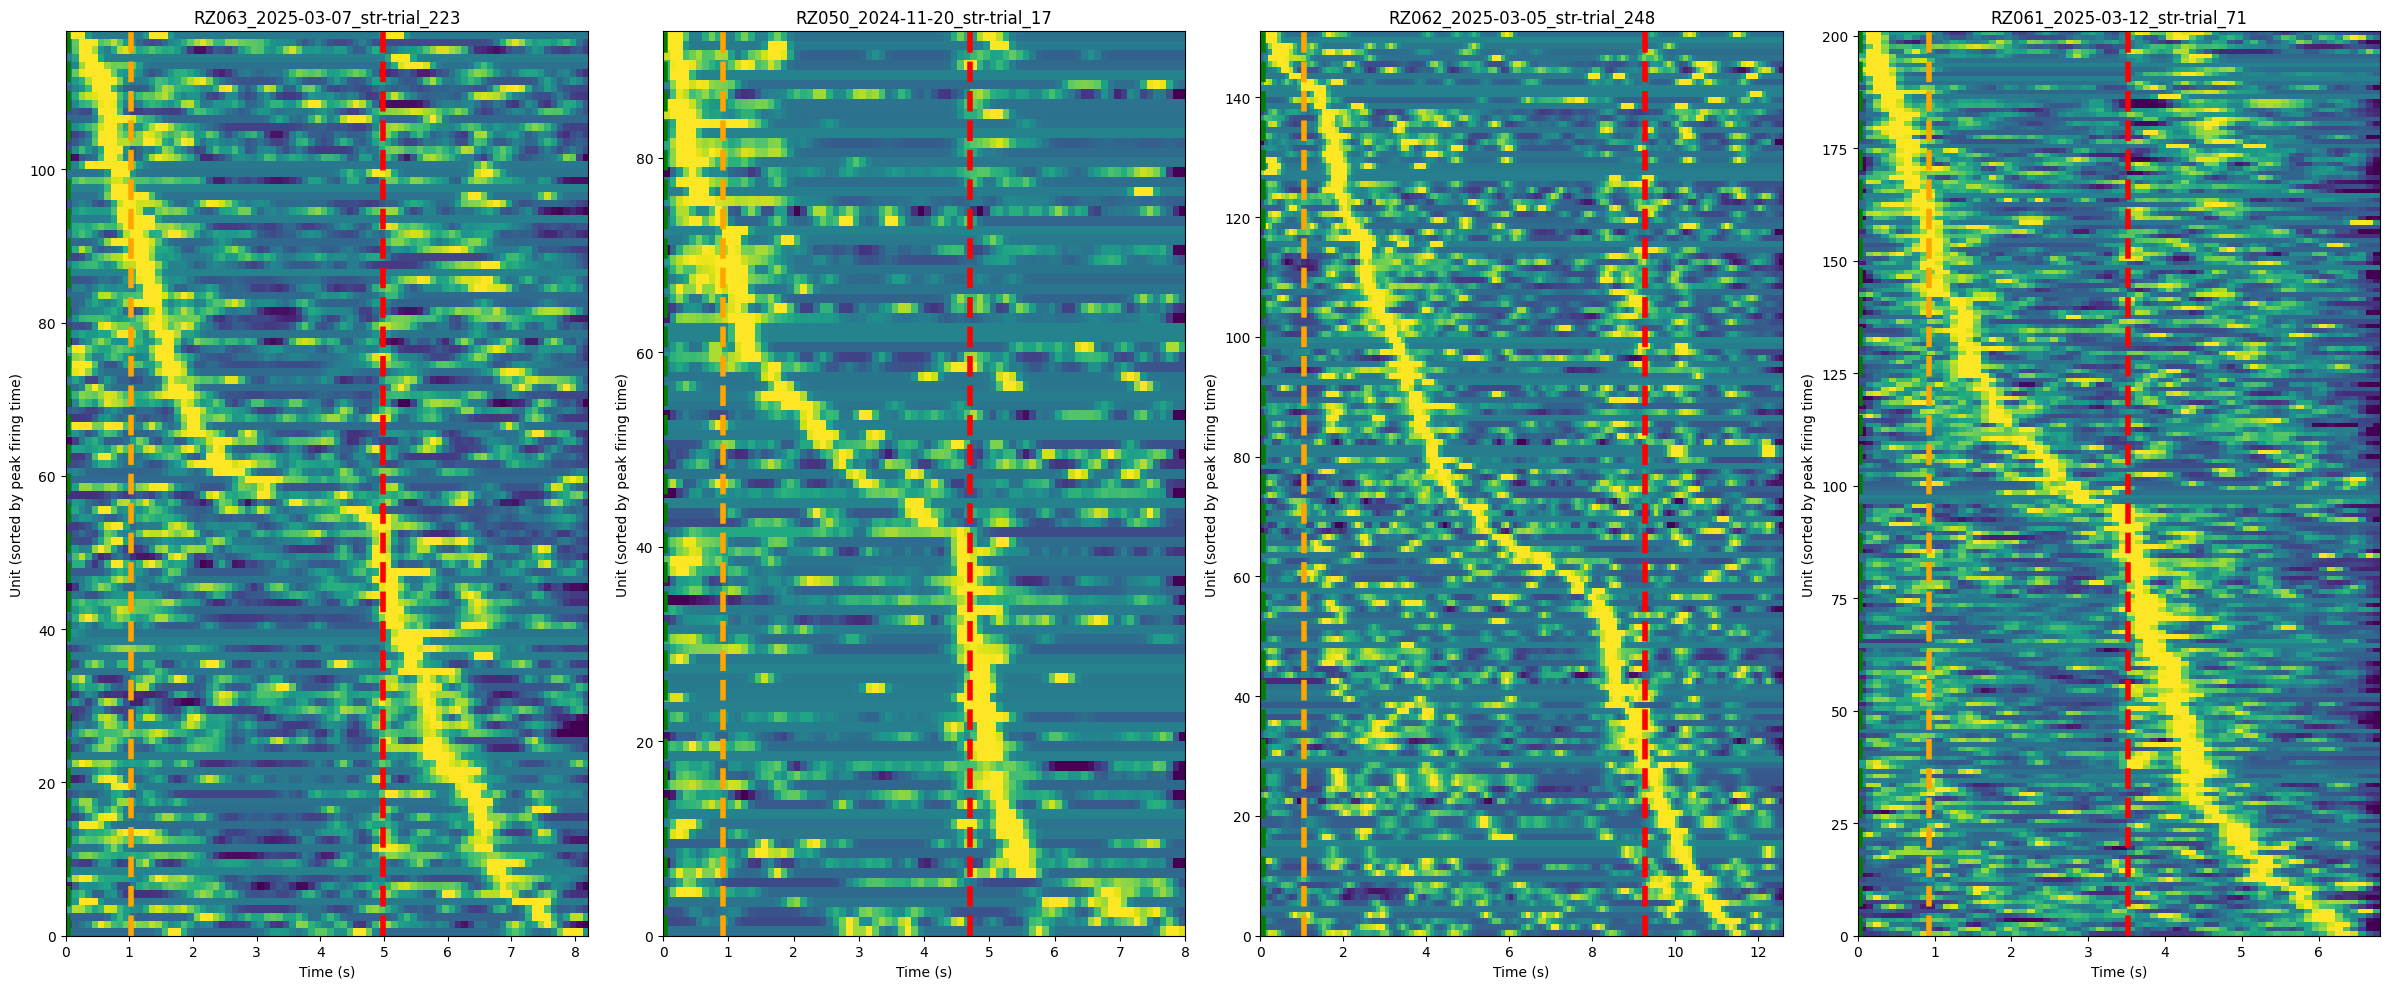

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(24, 10))
ims = []

for i, (session_id, trial_id) in enumerate(unrewarded_trials):
    session_info = sessions_vetted.loc[sessions_vetted['id'] == session_id].iloc[0]
    events, trials, units = utils.get_session_data(session_info['id'])
    trial_info = trials.loc[trials['trial_id'] == trial_id].iloc[0]

    trial_spikes_list = []
    for idx, unit in units.items():
        trial_spikes = unit.loc[unit['trial_id'] == trial_id].copy()
        if not trial_spikes.empty:
            trial_spikes.loc[:, 'unit_id'] = idx
            trial_spikes_list.append(trial_spikes)
    trial_spikes_df = pd.concat(trial_spikes_list)

    im = plot_trial_heatmap_on_ax(
        axes[i], trial_spikes_df, trial_info, session_info, time_step, sigma=1
    )
    ims.append(im)

plt.tight_layout()
plt.savefig(os.path.join(p.FIGURES_DIR, 'four_trial_heatmaps_unrewarded.png'))